In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [5]:
from zipfile import ZipFile

In [6]:
zip_path = "/content/drive/MyDrive/seg_test.zip"

extract_path = "/content/"

with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed!")

Extraction Completed!


In [7]:
zip_path = "/content/drive/MyDrive/seg_train.zip"

extract_path = "/content/"

with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed!")

Extraction Completed!


In [8]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/seg_train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.


In [10]:
for images, labels in train_ds.take(1):

    print("Images Shape :", images.shape)

    print("Labels Shape :", labels.shape)

Images Shape : (32, 224, 224, 3)
Labels Shape : (32,)


In [11]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/seg_test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3000 files belonging to 6 classes.


In [12]:
class_names = train_ds.class_names

print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


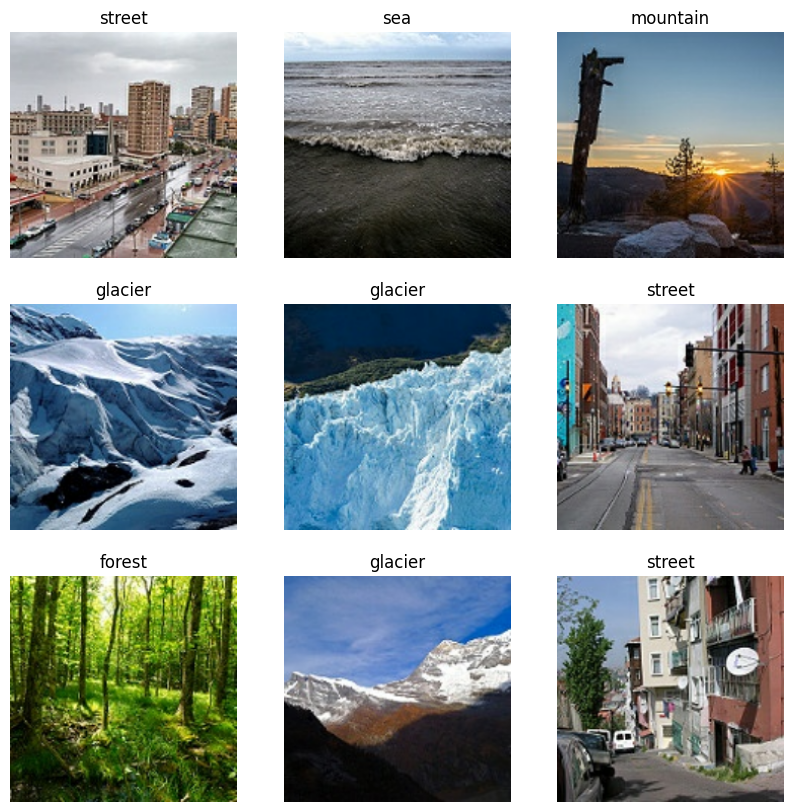

In [13]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [14]:
train_ds = train_ds.map(lambda x,y: (preprocess_input(x),y))

In [15]:
val_ds = val_ds.map(lambda x,y: (preprocess_input(x),y))

In [16]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
#Freeze the CNN layers
"""All pretrained convolutional weights remain unchanged.
Only the new layers we add later will learn."""

base_model.trainable = False

In [19]:
model = Sequential(
    [base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(6, activation="softmax")]
    )


In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)


In [24]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True
)

In [25]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)


In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 51s 115ms/step - accuracy: 0.9553 - loss: 0.1166 - val_accuracy: 0.9233 - val_loss: 0.2009
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.9647 - loss: 0.0944 - val_accuracy: 0.9330 - val_loss: 0.1937
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 51s 116ms/step - accuracy: 0.9690 - loss: 0.0780 - val_accuracy: 0.9343 - val_loss: 0.2251
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 49s 112ms/step - accuracy: 0.9764 - loss: 0.0639 - val_accuracy: 0.9270 - val_loss: 0.2288
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 118ms/step - accuracy: 0.9816 - loss: 0.0507 - val_accuracy: 0.9310 - val_loss: 0.2460
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.9815 - loss: 0.0524 - val_accuracy: 0.9213 - val_loss: 0.2547
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step - accuracy: 0.9843 - loss: 0.0419 - val_accuracy: 0.9323 - val_loss: 0.2653
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.9907 - loss: 0

In [27]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.9343 - loss: 0.2251
Validation Loss : 0.2250957489013672
Validation Accuracy : 0.934333324432373


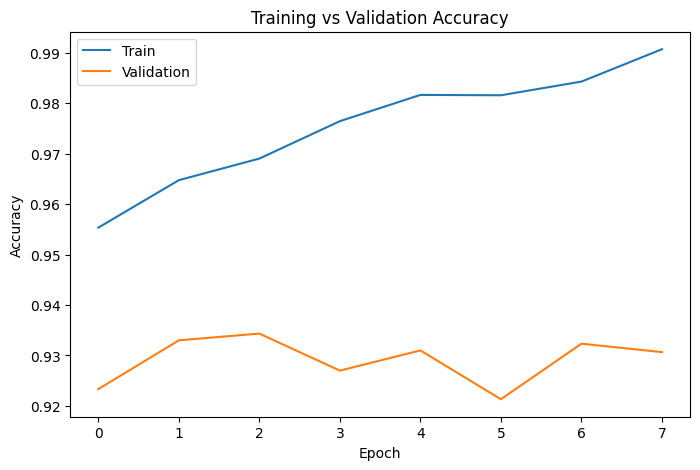

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# **FINE TUNING (BY TRAINING THE FEW CONVOLUTION LAYERS)**

In [29]:
base_model.trainable = True

In [30]:
len(base_model.layers)

175

In [31]:
len( base_model.layers[:-30])

145

In [32]:
#Freezing the 145 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [33]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer False
1 conv1_pad False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 pool1_pad False
6 pool1_pool False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_conv False
11 conv2_block1_2_bn False
12 conv2_block1_2_relu False
13 conv2_block1_0_conv False
14 conv2_block1_3_conv False
15 conv2_block1_0_bn False
16 conv2_block1_3_bn False
17 conv2_block1_add False
18 conv2_block1_out False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_conv False
23 conv2_block2_2_bn False
24 conv2_block2_2_relu False
25 conv2_block2_3_conv False
26 conv2_block2_3_bn False
27 conv2_block2_add False
28 conv2_block2_out False
29 conv2_block3_1_conv False
30 conv2_block3_1_bn False
31 conv2_block3_1_relu False
32 conv2_block3_2_conv False
33 conv2_block3_2_bn False
34 conv2_block3_2_relu False
35 conv2_block3_3_conv False
36 conv2_block3_3_bn False
37 conv2_block3_add False
38 conv2_

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 94s 170ms/step - accuracy: 0.9438 - loss: 0.1580 - val_accuracy: 0.9307 - val_loss: 0.2406
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 65s 147ms/step - accuracy: 0.9810 - loss: 0.0558 - val_accuracy: 0.9297 - val_loss: 0.2362
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 65s 149ms/step - accuracy: 0.9898 - loss: 0.0349 - val_accuracy: 0.9310 - val_loss: 0.2429
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 64s 145ms/step - accuracy: 0.9959 - loss: 0.0204 - val_accuracy: 0.9333 - val_loss: 0.2427
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 66s 149ms/step - accuracy: 0.9976 - loss: 0.0140 - val_accuracy: 0.9337 - val_loss: 0.2516


In [36]:
loss, accuracy = model.evaluate(val_ds)

print("Loss:", loss)
print("Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9307 - loss: 0.2406
Loss: 0.2406488060951233
Accuracy: 0.9306666851043701


In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
y_true = []
y_pred = []

for images, labels in val_ds:

    # Predict probabilities
    predictions = model.predict(images, verbose=0)

    # Convert probabilities to class index
    predicted_labels = np.argmax(predictions, axis=1)

    # Store results
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [39]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [40]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[406   0   2   0   2  27]
 [  0 470   3   1   0   0]
 [  1   1 490  44  16   1]
 [  4   3  61 450   6   1]
 [  0   0   6   4 499   1]
 [ 23   0   0   0   1 477]]


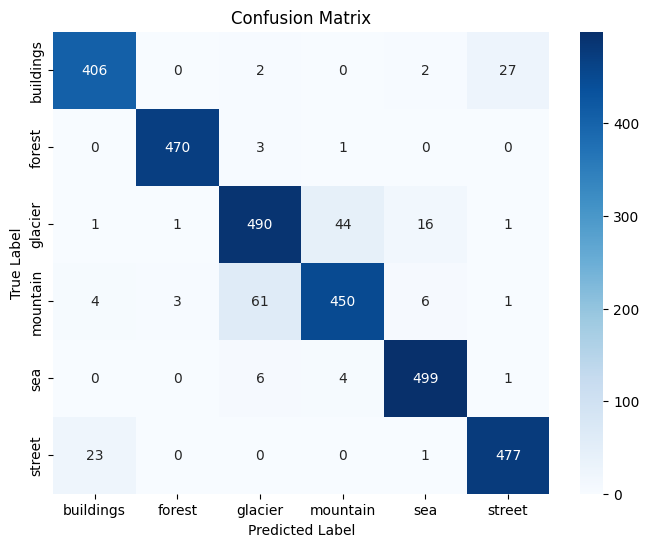

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [42]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   buildings       0.94      0.93      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.87      0.89      0.88       553
    mountain       0.90      0.86      0.88       525
         sea       0.95      0.98      0.97       510
      street       0.94      0.95      0.95       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



In [44]:
from tensorflow.keras.preprocessing import image

In [97]:
img = image.load_img(
    "/content/forest.jpg",
    target_size=(224,224)
)

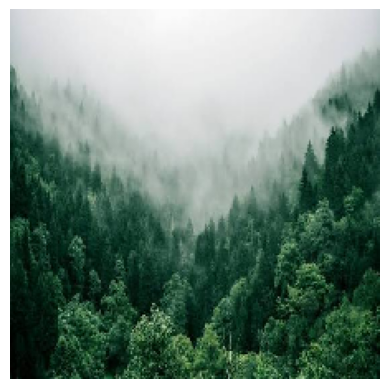

In [98]:
plt.imshow(img)
plt.axis("off")
plt.show()

In [99]:
img_array = image.img_to_array(img)

In [100]:
print(img_array.shape)

(224, 224, 3)


In [101]:
img_array = np.expand_dims(img_array, axis=0)

In [102]:
print(img_array.shape)

(1, 224, 224, 3)


In [103]:
img_array = preprocess_input(img_array)

In [104]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [105]:
print(prediction)

[[2.1831381e-06 9.9582964e-01 3.5089406e-03 3.4186261e-05 6.2509504e-04
  2.4146706e-08]]


In [106]:
predicted_index = np.argmax(prediction)

In [107]:
print(predicted_index)

1


In [108]:
predicted_class = class_names[predicted_index]

print(predicted_class)

forest


In [109]:
prediction = model.predict(img_array, verbose=0)

for cls, prob in zip(class_names, prediction[0]):
    print(f"{cls:12}: {prob:.4f}")

buildings   : 0.0000
forest      : 0.9958
glacier     : 0.0035
mountain    : 0.0000
sea         : 0.0006
street      : 0.0000
